# FASTA Predict

In [1]:
%pip install -qq --ignore-requires-python --no-deps 'graphies[predict] @ git+https://github.com/lukasmki/graphies.git'
%pip install -qq pydantic networkx datasets polars torch

import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
else:
    print(
        "CUDA is not available. Please ensure you have selected a GPU runtime in 'Runtime > Change runtime type'."
    )

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
Device name: NVIDIA A100-SXM4-40GB


## Setup Data Sources

In [2]:
!mkdir -p fasta-data
!wget -nv https://raw.githubusercontent.com/lukasmki/graphies-applications/refs/heads/main/grammars/fasta.json -O fasta-data/selfies.json

from pathlib import Path

GRAMMAR_PATH = next(Path().glob("fasta-data/*.json"))

2026-04-13 05:21:28 URL:https://raw.githubusercontent.com/lukasmki/graphies-applications/refs/heads/main/grammars/fasta.json [1615/1615] -> "fasta-data/selfies.json" [1]


In [3]:
from datasets import load_dataset

def transform_batch(batch: dict):
    fastas = []
    fasta_lengths = []
    for seq in batch["sequence"]:
        fastas.append("".join([f"[{c}]" for c in seq.lower()]))
        fasta_lengths.append(len(seq))

    return {"graphies": fastas, "fasta_lengths": fasta_lengths}

hf_dataset = load_dataset("lukaskim/ChEMBL-36", "targets", split="train")

hf_dataset = hf_dataset.map(
    transform_batch,
    batched=True,
    batch_size=1000,
    num_proc=4,
    desc="Encoding FASTA",
)

hf_dataset = hf_dataset.filter(
    lambda x: (x["graphies"] is not None) and (x["fasta_lengths"] < 1000),
    num_proc=4,
    desc="Filtering nulls",
)

README.md: 0.00B [00:00, ?B/s]

targets/train-00000-of-00001.parquet:   0%|          | 0.00/10.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16646 [00:00<?, ? examples/s]

Encoding FASTA (num_proc=4):   0%|          | 0/16646 [00:00<?, ? examples/s]

Filtering nulls (num_proc=4):   0%|          | 0/16646 [00:00<?, ? examples/s]

## Setup Data Loaders

In [4]:
from graphies.predict import GraphiesTokenizer, HFGraphiesDataset
from torch.utils.data import DataLoader, random_split

tokenizer = GraphiesTokenizer(GRAMMAR_PATH)
dataset = HFGraphiesDataset(
    hf_dataset, column="graphies", tokenizer=tokenizer, split=None
)

trn, tst = random_split(dataset, [0.9, 0.1])
torch.save(
    {"trn_indices": trn.indices, "tst_indices": tst.indices}, "fasta-data/split.pt"
)
trn_loader = DataLoader(
    dataset=trn,
    batch_size=256,
    shuffle=True,
    collate_fn=tokenizer.collate,
)
tst_loader = DataLoader(
    dataset=tst,
    batch_size=256,
    shuffle=False,
    collate_fn=tokenizer.collate,
)

## Trainer

In [5]:
from graphies.predict import GraphiesTrainer
from graphies.predict.models import GRU
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GRU(vocab_size=tokenizer.vocab_size)
optimizer = Adam(params=model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.1)

# include kwargs for classes to restart from checkpoitn
checkpoint = {
    "model_kwargs": {"vocab_size": tokenizer.vocab_size},
    "optimizer_kwargs": {"lr": 1e-3},
    "scheduler_kwargs": {"mode": "min", "patience": 3, "factor": 0.1},
}
trainer = GraphiesTrainer(model, optimizer, scheduler, device, checkpoint)

In [6]:
trainer.train(
    train=trn_loader,
    epochs=50,
    test=tst_loader,
    test_interval=1,
    log="fasta-data/log.csv",
    log_interval=1,
    checkpoint="fasta-data/chk.pt",
    checkpoint_interval=1,
)
trainer.save_model("fasta-data/model.pt")

Test 50: 100%|██████████| 6/6 [00:00<00:00,  6.91it/s, loss=2.1784]


In [8]:
# export to google drive
from google.colab import drive

drive.mount("/content/drive")
!zip -r fasta-data.zip fasta-data/
!cp fasta-data.zip '/content/drive/MyDrive/'

Mounted at /content/drive
  adding: fasta-data/ (stored 0%)
  adding: fasta-data/6-chk.pt (deflated 8%)
  adding: fasta-data/34-chk.pt (deflated 8%)
  adding: fasta-data/log.csv (deflated 50%)
  adding: fasta-data/42-chk.pt (deflated 8%)
  adding: fasta-data/19-chk.pt (deflated 8%)
  adding: fasta-data/30-chk.pt (deflated 8%)
  adding: fasta-data/17-chk.pt (deflated 8%)
  adding: fasta-data/26-chk.pt (deflated 8%)
  adding: fasta-data/35-chk.pt (deflated 8%)
  adding: fasta-data/7-chk.pt (deflated 8%)
  adding: fasta-data/48-chk.pt (deflated 8%)
  adding: fasta-data/model.pt (deflated 7%)
  adding: fasta-data/23-chk.pt (deflated 8%)
  adding: fasta-data/14-chk.pt (deflated 8%)
  adding: fasta-data/4-chk.pt (deflated 8%)
  adding: fasta-data/split.pt (deflated 26%)
  adding: fasta-data/13-chk.pt (deflated 8%)
  adding: fasta-data/10-chk.pt (deflated 8%)
  adding: fasta-data/29-chk.pt (deflated 8%)
  adding: fasta-data/12-chk.pt (deflated 8%)
  adding: fasta-data/40-chk.pt (deflated 8%)


# Run Inference

In [9]:
from graphies.predict import GraphiesModel

model = GraphiesModel.from_checkpoint(
    checkpoint="fasta-data/model.pt",
    tokenizer=tokenizer,
    model_cls=GRU,
    device=device,
)
sequences = model.generate(num=1024, temperature=0.9, top_p=0.95, max_len=5000)
ref_sequences = hf_dataset[tst.indices]['graphies']

In [10]:
%pip install -qq peptides pandas

import peptides as pt
import pandas as pd

def collect_descriptors(sequences):
    fastas = []
    for i, sequence in enumerate(sequences):
        graphies = tokenizer.strip(sequence)
        fasta = graphies.replace("[", "").replace("]", "").upper()
        pep = pt.Peptide(fasta)

        # Add scalar physicochemical properties alongside QSAR descriptors
        row = {}
        row["molecular_weight"] = pep.molecular_weight()
        row["isoelectric_point"] = pep.isoelectric_point()
        row["aliphatic_index"] = pep.aliphatic_index()
        row["instability_index"] = pep.boman()
        row["length"] = len(fasta)

        seq = fasta
        row["frac_hydrophobic"] = sum(seq.count(aa) for aa in "VILMFYW") / len(seq)
        row["frac_polar"] = sum(seq.count(aa) for aa in "STNQ") / len(seq)
        row["frac_charged"] = sum(seq.count(aa) for aa in "DEKRH") / len(seq)
        row["frac_aromatic"] = sum(seq.count(aa) for aa in "FYW") / len(seq)
        row["frac_proline"] = seq.count("P") / len(seq)  # helix-breaking, affects structure
        fastas.append(row)
    return pd.DataFrame(fastas)

df = collect_descriptors(sequences)
ref_df = collect_descriptors(ref_sequences)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 7.9 MB/s eta 0:00:00


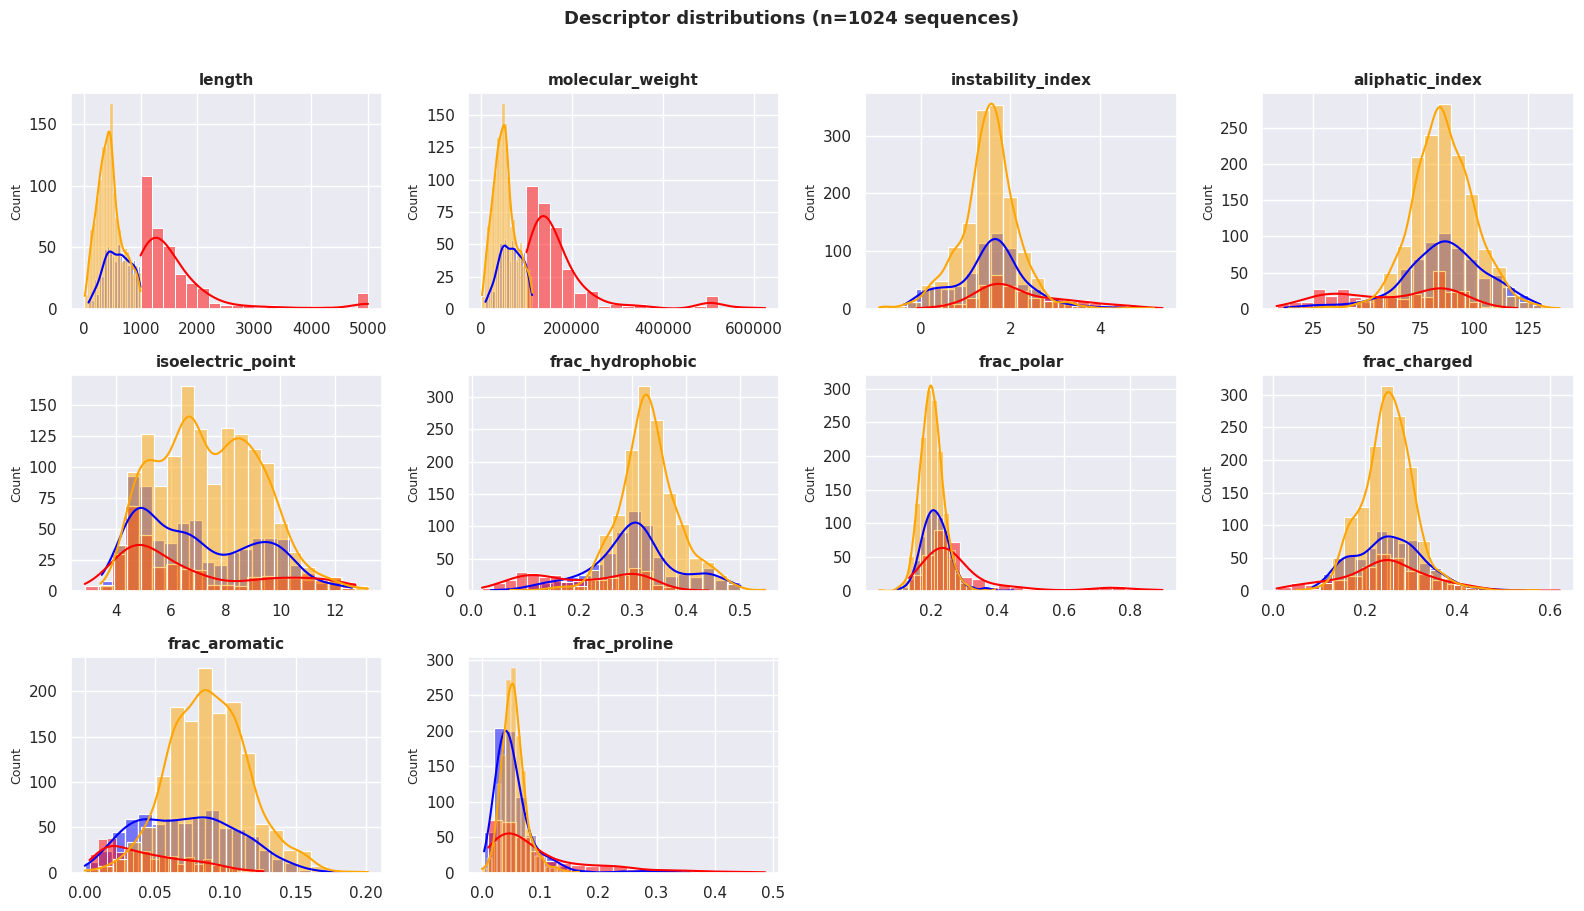

In [11]:
%pip install -qq seaborn matplotlib

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")

df_in = df[df["length"] < 1000]
df_out = df[df["length"] >= 1000]

# scalar physicochemical properties
plot_cols = [
    "length",
    "molecular_weight",
    "instability_index",
    "aliphatic_index",
    "isoelectric_point",
    "frac_hydrophobic",
    "frac_polar",
    "frac_charged",
    "frac_aromatic",
    "frac_proline",
]

n_cols = 4
n_rows = -(-len(plot_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    sns.histplot(data=df_in, x=col, bins=20, kde=True, ax=ax, color="blue", stat="count")
    sns.histplot(data=df_out, x=col, bins=20, kde=True, ax=ax, color="red", stat="count")
    sns.histplot(data=ref_df, x=col, bins=20, kde=True, ax=ax, color="orange", stat="count")
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=9)

for ax in axes[len(plot_cols):]:
    ax.set_visible(False)

fig.suptitle(f"Descriptor distributions (n={len(df)} sequences)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()